# Bruising Prediction CNN Test Result Analysis

Adapted from `/home/emahan/sysops/HIPPA/hanif/cnn/cnn_test_results_analysis.ipynb` for the bruising detection project outputs.

This notebook analyzes `reports/tables/cnn_test_predictions.csv`, summarizes train/validation/test splits, computes overall and grouped metrics, plots confusion matrices, compares warm/cold conditions, compares impact groups, and lists incorrect predictions for inspection.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

PROJECT_ROOT = Path('/home/emahan/sysops/HIPPA/hanif/bruising_detection')
TABLE_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'
REPO_FIGURE_DIR = PROJECT_ROOT / 'figures'
PREDICTIONS_CSV = TABLE_DIR / 'cnn_test_predictions.csv'
LABELS = [0, 1]
LABEL_NAMES = ['sound', 'bruised']

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REPO_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str):
    fig.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches='tight')
    fig.savefig(REPO_FIGURE_DIR / filename, dpi=200, bbox_inches='tight')

df = pd.read_csv(PREDICTIONS_CSV)
df['sample_id'] = df['file'].astype(str) + ' | ' + df['timepoint'].astype(str) + ' | ' + df['dataset'].astype(str)
df['microtec_id'] = df['file'].str.extract(r'MICROTEC_(\d+)')[0]
df['prefix2'] = df['microtec_id'].str[:2]
df['prefix3'] = df['microtec_id'].str[:3]
df['correct'] = df['y_true'].eq(df['y_pred'])

display(df.head())
print('Rows:', len(df))
print('Timepoints:', sorted(df['timepoint'].astype(str).unique()))
print('Files:', df['file'].nunique())


,path,file,group,timepoint,dataset,y,label,box_shape,crop_shape,bands,y_true,y_pred,y_true_label,y_pred_label,sample_id,microtec_id,prefix2,prefix3,correct
0,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_29203_processed_boxes.h5,SWIR_t0,t0,bruised1,0,sound,"(160, 160)","(160, 160)",220,0,0,sound,sound,MICROTEC_29203_processed_boxes.h5 | t0 | bruised1,29203,29,292,True
1,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_29203_processed_boxes.h5,SWIR_t0,t0,bruised2,0,sound,"(160, 160)","(160, 160)",220,0,0,sound,sound,MICROTEC_29203_processed_boxes.h5 | t0 | bruised2,29203,29,292,True
2,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_29203_processed_boxes.h5,SWIR_t0,t0,bruised3,0,sound,"(160, 160)","(160, 160)",220,0,0,sound,sound,MICROTEC_29203_processed_boxes.h5 | t0 | bruised3,29203,29,292,True
3,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_29203_processed_boxes.h5,SWIR_t0,t0,bruised4,0,sound,"(160, 160)","(160, 160)",220,0,0,sound,sound,MICROTEC_29203_processed_boxes.h5 | t0 | bruised4,29203,29,292,True
4,/srv/sysops/HIPPA/hanif/bruising_detection/dat...,MICROTEC_29203_processed_boxes.h5,SWIR_t0,t0,sound1,0,sound,"(160, 160)","(160, 160)",220,0,0,sound,sound,MICROTEC_29203_processed_boxes.h5 | t0 | sound1,29203,29,292,True


Rows: 384
Timepoints: ['t0', 't1', 't2', 't3']
Files: 12


## Train/Validation/Test Sample Counts

This block uses the saved project split sample CSVs in `data/splits`, so it reports the exact split files used by the current project results.


In [2]:
SPLIT_SAMPLE_CSVS = {
    'train': PROJECT_ROOT / 'data' / 'splits' / 'train_samples.csv',
    'val': PROJECT_ROOT / 'data' / 'splits' / 'val_samples.csv',
    'test': PROJECT_ROOT / 'data' / 'splits' / 'test_samples.csv',
}

split_rows = []
for split, path in SPLIT_SAMPLE_CSVS.items():
    split_df = pd.read_csv(path)
    split_rows.append({
        'split': split,
        'n_files': split_df['file'].nunique(),
        'n_samples': len(split_df),
        'n_sound': int((split_df['y'] == 0).sum()),
        'n_bruised': int((split_df['y'] == 1).sum()),
    })

split_summary = pd.DataFrame(split_rows)
total_files = int(split_summary['n_files'].sum())
total_samples = int(split_summary['n_samples'].sum())
total_sound = int(split_summary['n_sound'].sum())
total_bruised = int(split_summary['n_bruised'].sum())
split_summary['file_ratio'] = (split_summary['n_files'] / total_files).round(4)
split_summary['sample_ratio'] = (split_summary['n_samples'] / total_samples).round(4)
split_summary = pd.concat([
    split_summary,
    pd.DataFrame([{
        'split': 'total',
        'n_files': total_files,
        'n_samples': total_samples,
        'n_sound': total_sound,
        'n_bruised': total_bruised,
        'file_ratio': 1.0,
        'sample_ratio': 1.0,
    }]),
], ignore_index=True)

display(split_summary)
split_summary.to_csv(TABLE_DIR / 'bruising_prediction_split_sample_summary.csv', index=False)


,split,n_files,n_samples,n_sound,n_bruised,file_ratio,sample_ratio
0,train,94,3008,1880,1128,0.7966,0.7966
1,val,12,384,240,144,0.1017,0.1017
2,test,12,384,240,144,0.1017,0.1017
3,total,118,3776,2360,1416,1.0000,1.0000


In [3]:
def metric_row(data, name=None):
    y_true = data['y_true'].to_numpy()
    y_pred = data['y_pred'].to_numpy()
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=LABELS).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    row = {
        'n': int(len(data)),
        'correct': int((y_true == y_pred).sum()),
        'incorrect': int((y_true != y_pred).sum()),
        'true_negative': int(tn),
        'false_positive': int(fp),
        'false_negative': int(fn),
        'true_positive': int(tp),
        'n_true_positive_samples': int((y_true == 1).sum()),
        'n_predicted_positive_samples': int((y_pred == 1).sum()),
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
    }
    if name is not None:
        row = {'group': name, **row}
    return row


def metrics_by(data, group_col):
    return pd.DataFrame([metric_row(g, name) for name, g in data.groupby(group_col, sort=True)]).reset_index(drop=True)


def plot_confusion(cm, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(range(len(LABEL_NAMES)), LABEL_NAMES)
    ax.set_yticks(range(len(LABEL_NAMES)), LABEL_NAMES)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    threshold = cm.max() / 2 if cm.size and cm.max() else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > threshold else 'black')
    return im


## Overall Confusion Matrix

,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,overall,384,340,44,227,13,31,113,144,126,0.8854,0.8968,0.7847,0.837


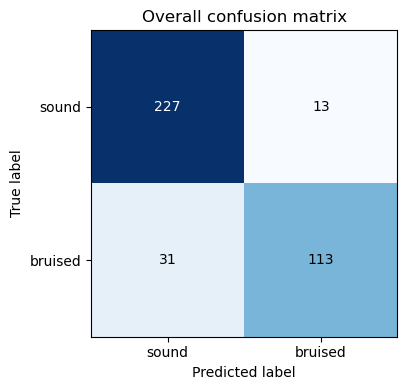

In [4]:
overall = pd.DataFrame([metric_row(df, 'overall')])
display(overall)
overall.to_csv(TABLE_DIR / 'bruising_prediction_test_overall_metrics.csv', index=False)

cm = confusion_matrix(df['y_true'], df['y_pred'], labels=LABELS)
fig, ax = plt.subplots(figsize=(4.5, 4))
plot_confusion(cm, 'Overall confusion matrix', ax=ax)
plt.tight_layout()
save_figure(fig, 'bruising_prediction_overall_confusion.png')
plt.show()


## Accuracy, Precision, Recall by Timepoint

In [5]:
timepoint_metrics = metrics_by(df, 'timepoint')
display(timepoint_metrics)
timepoint_metrics.to_csv(TABLE_DIR / 'bruising_prediction_test_metrics_by_timepoint.csv', index=False)


,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,t0,96,89,7,89,7,0,0,0,7,0.9271,0.0000,0.0000,0.0000
1,t1,96,85,11,47,1,10,38,48,39,0.8854,0.9744,0.7917,0.8736
2,t2,96,83,13,46,2,11,37,48,39,0.8646,0.9487,0.7708,0.8506
3,t3,96,83,13,45,3,10,38,48,41,0.8646,0.9268,0.7917,0.8539


## Confusion Matrix per Timepoint

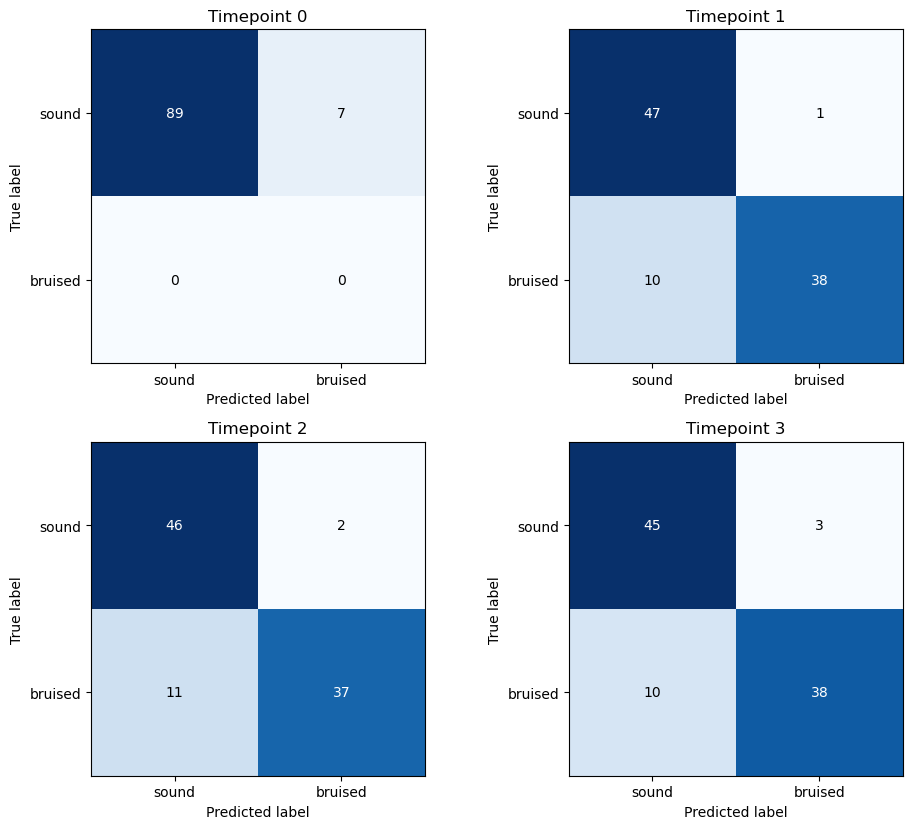

In [6]:
timepoints = sorted(df['timepoint'].astype(str).unique())
ncols = 2
nrows = int(np.ceil(len(timepoints) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, tp in zip(axes, timepoints):
    g = df[df['timepoint'].astype(str) == tp]
    cm = confusion_matrix(g['y_true'], g['y_pred'], labels=LABELS)
    plot_confusion(cm, f"Timepoint {str(tp).lstrip('t')}", ax=ax)

for ax in axes[len(timepoints):]:
    ax.axis('off')

plt.tight_layout()
save_figure(fig, 'bruising_prediction_timepoint_confusion.png')
plt.show()


## Comparison: Warm vs Cold Condition

Warm/cold groups are derived from the MICROTEC id prefix in the filename, matching the source notebook logic.


,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,warm,192,174,18,116,4,14,58,72,62,0.9062,0.9355,0.8056,0.8657
1,cold,192,166,26,111,9,17,55,72,64,0.8646,0.8594,0.7639,0.8088


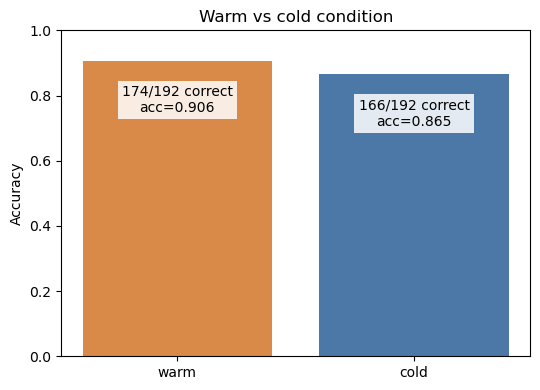

In [7]:
compare_warm_cold = df[df['prefix2'].isin(['28', '29'])].copy()
compare_warm_cold['comparison_group'] = compare_warm_cold['prefix2'].map({'28': 'warm', '29': 'cold'})
metrics_warm_cold = metrics_by(compare_warm_cold, 'comparison_group')
metrics_warm_cold = metrics_warm_cold.set_index('group').loc[['warm', 'cold']].reset_index()
display(metrics_warm_cold)
metrics_warm_cold.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_warm_cold.csv', index=False)

fig, ax = plt.subplots(figsize=(5.5, 4.0))
bars = ax.bar(metrics_warm_cold['group'], metrics_warm_cold['accuracy'], color=['#d98948', '#4c78a8'])
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Warm vs cold condition')
for bar, (_, row) in zip(bars, metrics_warm_cold.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        max(row['accuracy'] - 0.12, 0.08),
        f"{row['correct']}/{row['n']} correct\nacc={row['accuracy']:.3f}",
        ha='center', va='center', color='black', fontsize=10,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 3},
    )
plt.tight_layout()
save_figure(fig, 'bruising_prediction_warm_cold_accuracy.png')
plt.show()


## Comparison: Low, Medium, and High Impact

Impact groups are derived from the first three digits of the MICROTEC id, matching the project EDA grouping.


,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,low impact,96,73,23,51,9,14,22,36,31,0.7604,0.7097,0.6111,0.6567
1,medium impact,96,79,17,60,0,17,19,36,19,0.8229,1.0000,0.5278,0.6909
2,high impact,192,188,4,116,4,0,72,72,76,0.9792,0.9474,1.0000,0.9730


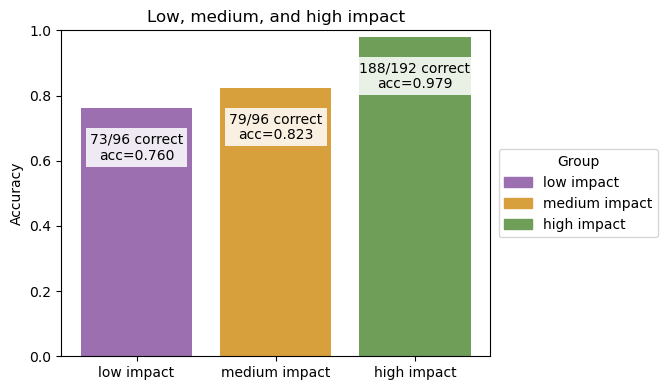

In [8]:
low_impact_prefixes = {'280', '281', '290', '291'}
medium_impact_prefixes = {'282', '292', '283', '293'}
high_impact_prefixes = {'284', '285', '294', '295'}


def impact_group(prefix):
    if prefix in low_impact_prefixes:
        return 'low impact'
    if prefix in medium_impact_prefixes:
        return 'medium impact'
    if prefix in high_impact_prefixes:
        return 'high impact'
    return np.nan

compare_impact_groups = df.copy()
compare_impact_groups['comparison_group'] = compare_impact_groups['prefix3'].map(impact_group)
compare_impact_groups = compare_impact_groups.dropna(subset=['comparison_group'])
metrics_impact_groups = metrics_by(compare_impact_groups, 'comparison_group')
metrics_impact_groups = metrics_impact_groups.set_index('group').loc[['low impact', 'medium impact', 'high impact']].reset_index()
display(metrics_impact_groups)
metrics_impact_groups.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_impact_groups.csv', index=False)

fig, ax = plt.subplots(figsize=(6.8, 4.0))
colors = {'low impact': '#9b6fb0', 'medium impact': '#d8a03d', 'high impact': '#6f9e59'}
bars = ax.bar(
    metrics_impact_groups['group'],
    metrics_impact_groups['accuracy'],
    color=[colors[g] for g in metrics_impact_groups['group']],
)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Low, medium, and high impact')
for bar, (_, row) in zip(bars, metrics_impact_groups.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        max(row['accuracy'] - 0.12, 0.08),
        f"{row['correct']}/{row['n']} correct\nacc={row['accuracy']:.3f}",
        ha='center', va='center', color='black', fontsize=10,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 3},
    )
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=colors[name], label=name) for name in ['low impact', 'medium impact', 'high impact']]
ax.legend(handles=legend_handles, title='Group', loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.tight_layout()
save_figure(fig, 'bruising_prediction_impact_accuracy.png')
plt.show()


## Comparison: Low, Medium, and High Impact

,group,n,correct,incorrect,true_negative,false_positive,false_negative,true_positive,n_true_positive_samples,n_predicted_positive_samples,accuracy,precision,recall,f1
0,low impact,96,73,23,51,9,14,22,36,31,0.7604,0.7097,0.6111,0.6567
1,medium impact,96,79,17,60,0,17,19,36,19,0.8229,1.0000,0.5278,0.6909
2,high impact,192,188,4,116,4,0,72,72,76,0.9792,0.9474,1.0000,0.9730


Files per group


,comparison_group,prefix3,n_files
0,high impact,284,2
1,high impact,285,2
2,high impact,294,1
3,high impact,295,1
4,low impact,280,1
5,low impact,281,1
6,low impact,290,1
7,medium impact,292,1
8,medium impact,293,2


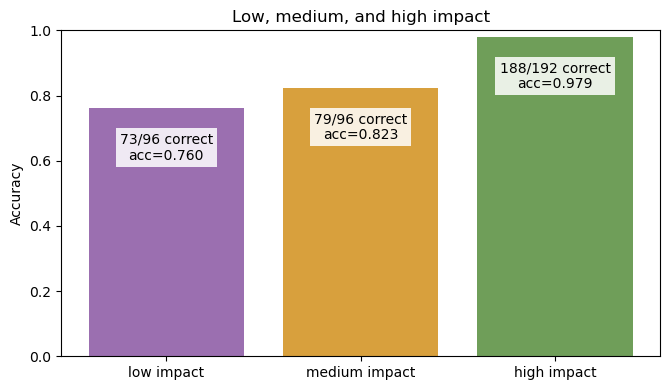

In [9]:
low_impact_prefixes = {'280', '281', '290', '291'}
medium_impact_prefixes = {'282', '292', '283', '293'}
high_impact_prefixes = {'284', '285', '294', '295'}


def impact_group_three_level(prefix):
    if prefix in low_impact_prefixes:
        return 'low impact'
    if prefix in medium_impact_prefixes:
        return 'medium impact'
    if prefix in high_impact_prefixes:
        return 'high impact'
    return np.nan

compare_three_groups = df.copy()
compare_three_groups['comparison_group'] = compare_three_groups['prefix3'].map(impact_group_three_level)
compare_three_groups = compare_three_groups.dropna(subset=['comparison_group'])
metrics_three_groups = metrics_by(compare_three_groups, 'comparison_group')
metrics_three_groups = metrics_three_groups.set_index('group').loc[['low impact', 'medium impact', 'high impact']].reset_index()
display(metrics_three_groups)
metrics_three_groups.to_csv(TABLE_DIR / 'bruising_prediction_test_compare_three_impact_groups.csv', index=False)

print('Files per group')
display(compare_three_groups.drop_duplicates('file').groupby(['comparison_group', 'prefix3']).size().rename('n_files').reset_index())

fig, ax = plt.subplots(figsize=(6.8, 4.0))
colors = {'low impact': '#9b6fb0', 'medium impact': '#d8a03d', 'high impact': '#6f9e59'}
bars = ax.bar(
    metrics_three_groups['group'],
    metrics_three_groups['accuracy'],
    color=[colors[g] for g in metrics_three_groups['group']],
)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Low, medium, and high impact')
for bar, (_, row) in zip(bars, metrics_three_groups.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        max(row['accuracy'] - 0.12, 0.08),
        f"{row['correct']}/{row['n']} correct\nacc={row['accuracy']:.3f}",
        ha='center', va='center', color='black', fontsize=10,
        bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 3},
    )
plt.tight_layout()
save_figure(fig, 'bruising_prediction_three_impact_accuracy.png')
plt.show()


## Incorrect Predictions for Inspection

In [10]:
errors = df[~df['correct']].copy()
error_columns = ['file', 'microtec_id', 'timepoint', 'dataset', 'y_true_label', 'y_pred_label', 'y_true', 'y_pred']
display(errors[error_columns])
errors[error_columns].to_csv(TABLE_DIR / 'bruising_prediction_test_incorrect_predictions.csv', index=False)
print('Incorrect predictions:', len(errors), 'of', len(df))


,file,microtec_id,timepoint,dataset,y_true_label,y_pred_label,y_true,y_pred
10,MICROTEC_29203_processed_boxes.h5,29203,t1,bruised3,damaged,sound,1,0
11,MICROTEC_29203_processed_boxes.h5,29203,t1,bruised4,damaged,sound,1,0
18,MICROTEC_29203_processed_boxes.h5,29203,t2,bruised3,damaged,sound,1,0
25,MICROTEC_29203_processed_boxes.h5,29203,t3,bruised2,damaged,sound,1,0
26,MICROTEC_29203_processed_boxes.h5,29203,t3,bruised3,damaged,sound,1,0
72,MICROTEC_28008_processed_boxes.h5,28008,t1,bruised1,damaged,sound,1,0
73,MICROTEC_28008_processed_boxes.h5,28008,t1,bruised2,damaged,sound,1,0
74,MICROTEC_28008_processed_boxes.h5,28008,t1,bruised3,damaged,sound,1,0
75,MICROTEC_28008_processed_boxes.h5,28008,t1,bruised4,damaged,sound,1,0
79,MICROTEC_28008_processed_boxes.h5,28008,t1,sound4,sound,damaged,0,1


Incorrect predictions: 44 of 384
